# Model Comparison

This notebook compares the performance of the Logistic Regression and Random Forest classifiers developed for predicting documented diabetes.

The comparison focuses on:

- predictive performance
- model strengths
- feature importance
- clinical interpretation

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

In [2]:
project_root = Path.cwd().parent

model_output_dir = project_root / "outputs" / "models"

In [3]:
logistic_metrics = pd.read_csv(
    model_output_dir / "logistic_regression_metrics.csv"
)

random_forest_metrics = pd.read_csv(
    model_output_dir / "random_forest_metrics.csv"
)

In [4]:
logistic_metrics

,Metric,Value
0,Accuracy,0.752
1,Precision,0.702
2,Recall,0.719
3,F1 score,0.710
4,ROC AUC,0.846


In [6]:
random_forest_metrics

,Metric,Value
0,Accuracy,0.746
1,Precision,0.686
2,Recall,0.739
3,F1 score,0.711
4,ROC AUC,0.838


In [9]:
comparison = (
    logistic_metrics
    .merge(
        random_forest_metrics,
        on="Metric",
        suffixes=(
            "_Logistic",
            "_RandomForest"
        )
    )
)

comparison.columns = [
    "Metric",
    "Logistic Regression",
    "Random Forest"
]

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.752,0.746
1,Precision,0.702,0.686
2,Recall,0.719,0.739
3,F1 score,0.710,0.711
4,ROC AUC,0.846,0.838


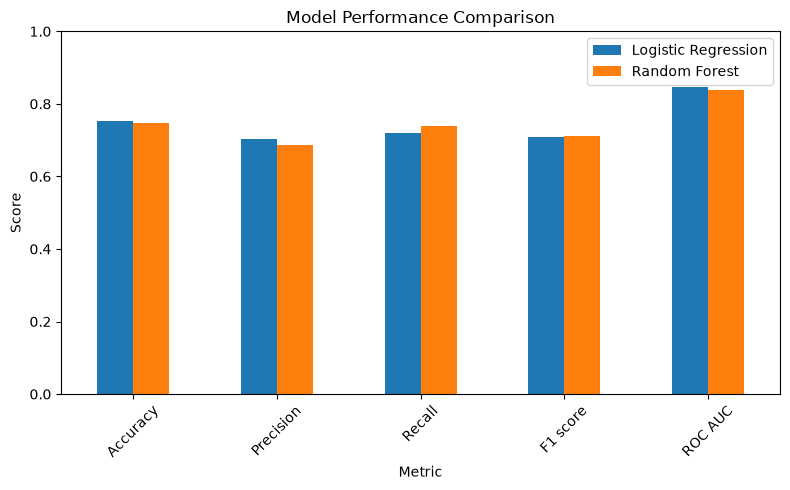

In [10]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Score")
plt.ylim(0,1)
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
rf_feature_importance = pd.read_csv(
    model_output_dir / "random_forest_feature_importance.csv"
)

rf_feature_importance

,Feature,Importance
0,numeric__age,0.400446
1,numeric__bmi,0.280086
2,numeric__encounter_count,0.251424
3,binary__hypertension,0.050842
4,categorical__gender_M,0.017202


## Model Selection

Both Logistic Regression and Random Forest demonstrated similar predictive performance when predicting documented diabetes.

Although Random Forest achieved slightly higher recall (0.739 vs. 0.720), Logistic Regression produced higher overall accuracy (0.750 vs. 0.746), higher precision (0.700 vs. 0.686), and a slightly higher ROC AUC
(0.846 vs. 0.838).

The differences between the two models were relatively small, suggesting that the available predictors exhibit largely linear relationships with the outcome.
With only five predictor variables, there is limited opportunity for Random Forest to exploit complex non-linear interactions.

For this project, Logistic Regression would be the preferred model because it provides comparable predictive performance while remaining considerably easier to interpret. In healthcare analytics, model interpretability is often an important consideration alongside predictive accuracy, as clinicians and stakeholders need to understand how predictions are generated.

## Discussion

This project demonstrated an end-to-end machine learning workflow for predicting documented diabetes using synthetic electronic health record data.

Two classification algorithms were evaluated: Logistic Regression and Random Forest. Despite the increased complexity of Random Forest, its performance was very similar to that of Logistic Regression. This suggests that the selected predictors (age, BMI, encounter count, hypertension, and gender) provide a relationship with diabetes that is adequately captured by a linear model.

Random Forest identified age as the most influential predictor, followed by BMI and encounter count. Hypertension contributed comparatively less predictive information, while gender had minimal influence on model predictions. These findings are broadly consistent with established clinical knowledge regarding risk factors associated with diabetes.

Overall, this comparison highlights that more complex machine learning models do not always outperform simpler statistical models. Model selection should consider predictive performance, interpretability, computational efficiency, and the intended clinical application.

## Limitations

Several limitations should be considered when interpreting these results.

- The analysis was performed using synthetic Synthea data rather than real patient records.

- Only five predictor variables were included in the model. Important clinical factors such as smoking status, laboratory measurements, medications, ethnicity, family history, and lifestyle factors were unavailable.

- Approximately 2.7% of BMI values were missing and were imputed using the median calculated from the training dataset.

- Hyperparameter optimisation was not performed for either model. Further tuning may improve predictive performance.

- Model performance was evaluated using a single train-test split rather than repeated cross-validation, which may provide a more robust estimate of generalisation performance.

# Conclusion

This project successfully developed and evaluated two machine learning models for predicting documented diabetes using synthetic electronic health record data.

Both Logistic Regression and Random Forest achieved comparable predictive performance. Logistic Regression demonstrated slightly higher overall accuracy, precision, and ROC AUC, while Random Forest achieved a marginal improvement in recall. Given the small performance differences, Logistic Regression was selected as the preferred model because of its simplicity, interpretability, and lower computational complexity.

The project demonstrates a complete end-to-end healthcare analytics workflow, including SQL-based feature engineering, exploratory data analysis in R, machine learning model development in Python, and comparative model evaluation.
Although the dataset was synthetic and limited in scope, the workflow provides a reproducible foundation that can be extended to more complex clinical prediction tasks using real-world healthcare data.